### Importing

In [107]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split , GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import ConfusionMatrixDisplay , classification_report , PrecisionRecallDisplay , RocCurveDisplay

### Loading Data

In [ ]:
df = pd.read_csv(filepath_or_buffer = "hearing_test.csv")
df.head()

,age,physical_score,test_result
0,33.0,40.7,1
1,50.0,37.2,1
2,52.0,24.7,0
3,56.0,31.0,0
4,35.0,42.9,1


### EDA

In [71]:
df.shape

(5000, 3)

In [72]:
df.columns

Index(['age', 'physical_score', 'test_result'], dtype='object')

In [73]:
df.duplicated().sum()

np.int64(1470)

In [74]:
df = df.drop_duplicates()

In [75]:
df.isnull().sum()

age               0
physical_score    0
test_result       0
dtype: int64

In [76]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3530 entries, 0 to 4998
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             3530 non-null   float64
 1   physical_score  3530 non-null   float64
 2   test_result     3530 non-null   int64  
dtypes: float64(2), int64(1)
memory usage: 110.3 KB


In [77]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,3530.0,53.202550,11.886973,18.0,45.0,54.0,62.0,90.0
physical_score,3530.0,31.459433,8.627548,-0.0,24.7,33.3,38.3,50.0
test_result,3530.0,0.502550,0.500064,0.0,0.0,1.0,1.0,1.0


In [78]:
df["age"] = df["age"].astype("int64")

In [79]:
df = df.drop(index = df[df["physical_score"] == -0.0].index)

In [80]:
df["test_result"].value_counts()

test_result
1    1774
0    1755
Name: count, dtype: int64

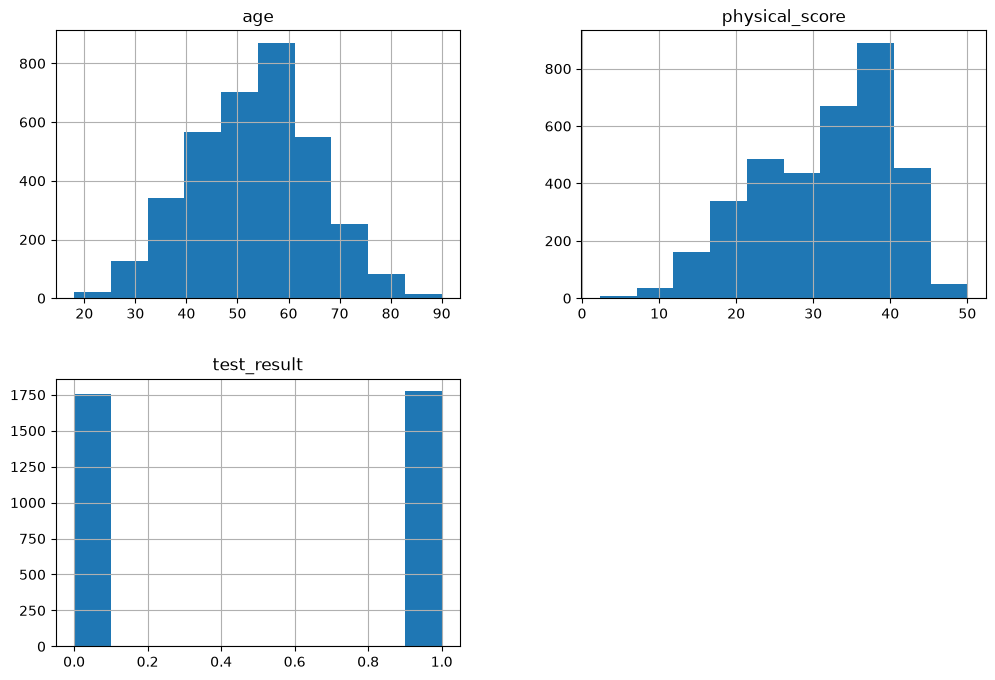

In [81]:
df.hist(figsize = (12 , 8))
plt.show()

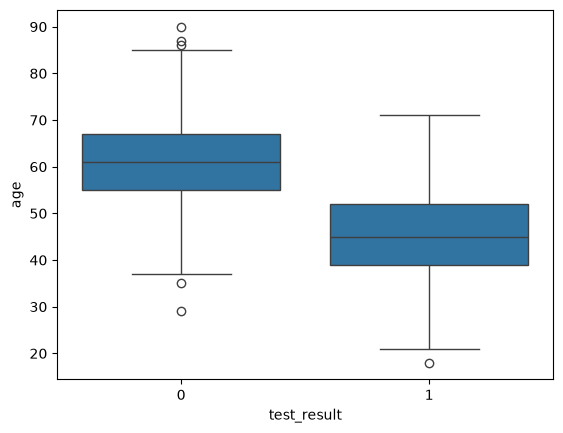

In [82]:
sns.boxplot(data = df , x = "test_result" , y = "age")
plt.show()

In [83]:
df = df.drop(index = df[(df["test_result"] == 0) & (df["age"] < 38)].index)

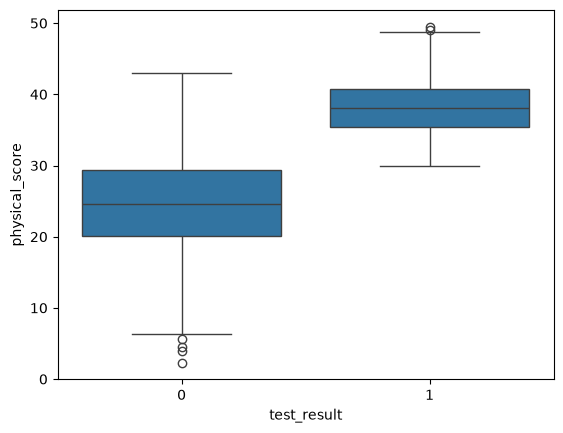

In [87]:
sns.boxplot(data = df , x = "test_result" , y = "physical_score")
plt.show()

In [86]:
df = df.drop(index = df[(df["test_result"] == 0) & (df["physical_score"] > 43)].index)
df = df.drop(index = df[(df["test_result"] == 1) & (df["physical_score"] < 30)].index)

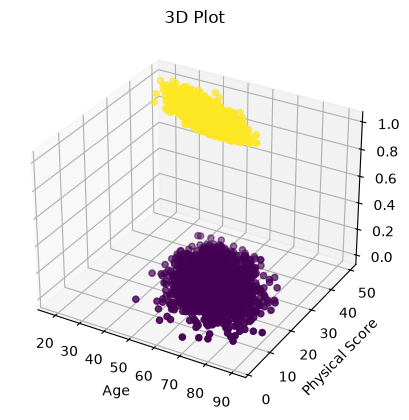

In [90]:
fig = plt.figure()
ax = fig.add_subplot(111 , projection = "3d")
ax.scatter(xs = df["age"] , ys = df["physical_score"] , zs = df["test_result"] , c = df["test_result"])

plt.title("3D Plot")
plt.xlabel("Age")
plt.ylabel("Physical Score")
plt.show()

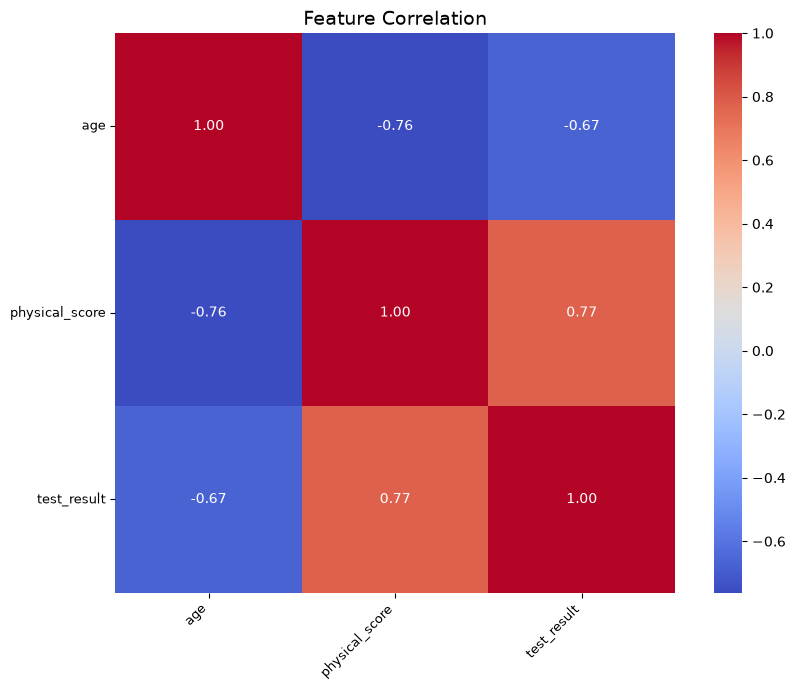

In [91]:
plt.figure(figsize = (9 , 7))
sns.heatmap(df.corr() , annot = True , fmt = ".2f" , square = True , cmap = "coolwarm")

plt.title("Feature Correlation" , fontsize = 14)
plt.xticks(rotation = 45 , ha = "right" , fontsize = 9)
plt.yticks(rotation = 0 , fontsize = 9)
plt.tight_layout()
plt.show()

### Feature & Target Split

In [92]:
X = df.drop(columns = ["test_result"])
y = df["test_result"]

### Train & Test Split

In [93]:
X_train , X_test , y_train , y_test = train_test_split(X , y , test_size = 0.15 , random_state = 101)

### Making Pipeline

In [94]:
scaler = StandardScaler()
model = LogisticRegression(l1_ratio = 0 , max_iter = 300000 , random_state = 101) # l1_ratio = 0 --> Ridge(L2)

In [95]:
pipe = Pipeline([("scaler" , scaler) , ("model" , model)])

### GridSearchCV & Model Training

In [96]:
param_grid = {"model__solver" : ["lbfgs" , "liblinear" , "saga"]}

In [105]:
grid_model = GridSearchCV(estimator = pipe , param_grid = param_grid , cv = 5 , scoring = "accuracy")
grid_model.fit(X_train , y_train)
grid_model.best_params_

{'model__solver': 'lbfgs'}

### Predication

In [106]:
y_pred = grid_model.predict(X_test)

### Evaluation

In [108]:
print(classification_report(y_test , y_pred))

              precision    recall  f1-score   support

           0       0.93      0.90      0.91       257
           1       0.91      0.93      0.92       267

    accuracy                           0.92       524
   macro avg       0.92      0.92      0.92       524
weighted avg       0.92      0.92      0.92       524



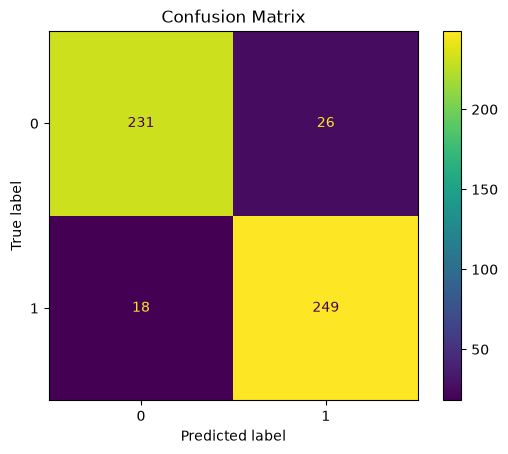

In [111]:
ConfusionMatrixDisplay.from_estimator(estimator = grid_model , X = X_test , y = y_test)
plt.title("Confusion Matrix")
plt.show()

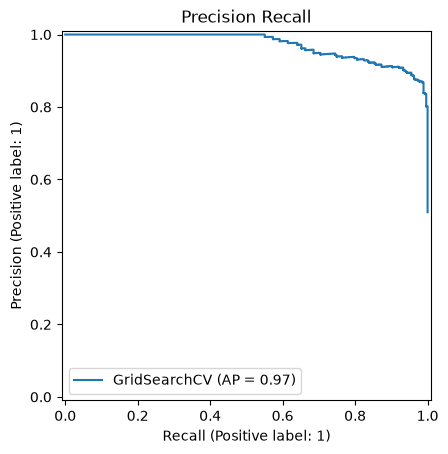

In [113]:
PrecisionRecallDisplay.from_estimator(estimator = grid_model , X = X_test , y = y_test)
plt.title("Precision Recall")
plt.show()

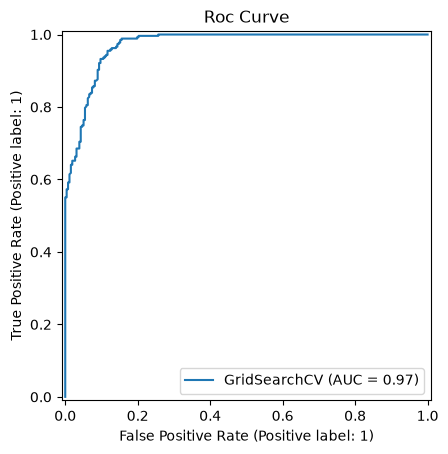

In [114]:
RocCurveDisplay.from_estimator(estimator = grid_model , X = X_test , y = y_test)
plt.title("Roc Curve")
plt.show()